In [ ]:
!pip install pretty_midi torch matplotlib tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 61.3 MB/s eta 0:00:0000:01:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.6 MB/s eta 0:00:00
  Created wheel for pretty_midi: filename=pretty_midi-0.2.11-py3-none-any.whl size=5595886 sha256=4cde4b285f30fc0f66dc1fc0dd4e7ae77d4afa174c80cae249edcd99523ea280
  Stored in directory: /root/.cache/pip/wheels/f4/ad/93/a7042fe12668827574927ade9deec7f29aad2a1001b1501882
Successfully built pretty_midi


In [ ]:
import os
import numpy as np
import pretty_midi
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [ ]:
DATA_PATH = "/kaggle/input/datasets/jihadjbjjuihhih/clean-sub/genre_dataset"

SEQ_LEN = 64
STEP = 32
BATCH_SIZE = 32
LATENT_DIM = 128
EPOCHS = 20

GENRE_TO_IDX = {
    "jazz": 0,
    "classical": 1,
    "rock": 2
}

In [ ]:
def midi_to_pianoroll(path, fs=10):
    try:
        midi = pretty_midi.PrettyMIDI(path)
        roll = midi.get_piano_roll(fs=fs)
        roll = (roll > 0).astype(np.float32)
        return roll.T  # (time, 128)
    except:
        return None

In [ ]:
def create_sequences(data, seq_len=64, step=32):
    sequences = []
    for i in range(0, len(data) - seq_len, step):
        sequences.append(data[i:i+seq_len])
    return sequences

In [ ]:
X = []
Y = []

for genre in os.listdir(DATA_PATH):
    genre_path = os.path.join(DATA_PATH, genre)

    if genre not in GENRE_TO_IDX:
        continue

    label = GENRE_TO_IDX[genre]

    files = os.listdir(genre_path)[:100]  # subset

    for f in tqdm(files, desc=genre):
        path = os.path.join(genre_path, f)

        roll = midi_to_pianoroll(path)
        if roll is None or len(roll) < SEQ_LEN:
            continue

        seqs = create_sequences(roll)

        for s in seqs:
            X.append(s)
            Y.append(label)

X = np.array(X)
Y = np.array(Y)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

rock:  19%|█▉        | 19/100 [00:05<00:24,  3.37it/s]/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
jazz: 100%|██████████| 100/100 [00:18<00:00,  5.32it/s]


X shape: (22190, 64, 128)
Y shape: (22190,)


In [ ]:
class MIDIDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [ ]:
dataset = MIDIDataset(X, Y)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim=128, hidden_dim=256, latent_dim=128, num_classes=3):
        super().__init__()

        self.embedding = nn.Embedding(num_classes, 16)

        self.encoder = nn.Sequential(
            nn.Linear(input_dim * SEQ_LEN + 16, hidden_dim),
            nn.ReLU(),
        )

        self.mu = nn.Linear(hidden_dim, latent_dim)
        self.logvar = nn.Linear(hidden_dim, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + 16, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim * SEQ_LEN),
            nn.Sigmoid()
        )

    def encode(self, x, y):
        y_embed = self.embedding(y)
        x = x.view(x.size(0), -1)
        x = torch.cat([x, y_embed], dim=1)

        h = self.encoder(x)
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, y):
        y_embed = self.embedding(y)
        z = torch.cat([z, y_embed], dim=1)
        out = self.decoder(z)
        return out.view(-1, SEQ_LEN, 128)

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z, y)
        return recon, mu, logvar

In [ ]:
def vae_loss(recon_x, x, mu, logvar, beta=0.1):
    recon_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')

    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + beta * kl

Epoch 5/150 - Total: 197.8198, Recon: 183.4953, KL: 14.3245
Epoch 10/150 - Total: 187.3188, Recon: 169.1460, KL: 18.1728
Epoch 15/150 - Total: 182.3118, Recon: 162.1343, KL: 20.1774
Epoch 20/150 - Total: 179.2888, Recon: 157.8661, KL: 21.4227
Epoch 25/150 - Total: 177.3433, Recon: 154.9826, KL: 22.3607
Epoch 30/150 - Total: 175.7555, Recon: 152.6812, KL: 23.0743
Epoch 35/150 - Total: 174.7563, Recon: 151.1240, KL: 23.6324
Epoch 40/150 - Total: 174.0143, Recon: 149.9916, KL: 24.0227
Epoch 45/150 - Total: 173.2504, Recon: 148.9507, KL: 24.2997
Epoch 50/150 - Total: 172.7040, Recon: 148.0976, KL: 24.6065
Epoch 55/150 - Total: 172.3316, Recon: 147.4002, KL: 24.9314
Epoch 60/150 - Total: 171.7177, Recon: 146.6764, KL: 25.0413
Epoch 65/150 - Total: 171.5850, Recon: 146.2356, KL: 25.3494
Epoch 70/150 - Total: 171.0424, Recon: 145.6696, KL: 25.3728
Epoch 75/150 - Total: 170.8280, Recon: 145.2580, KL: 25.5701
Epoch 80/150 - Total: 170.4913, Recon: 144.8067, KL: 25.6846
Epoch 85/150 - Total: 170

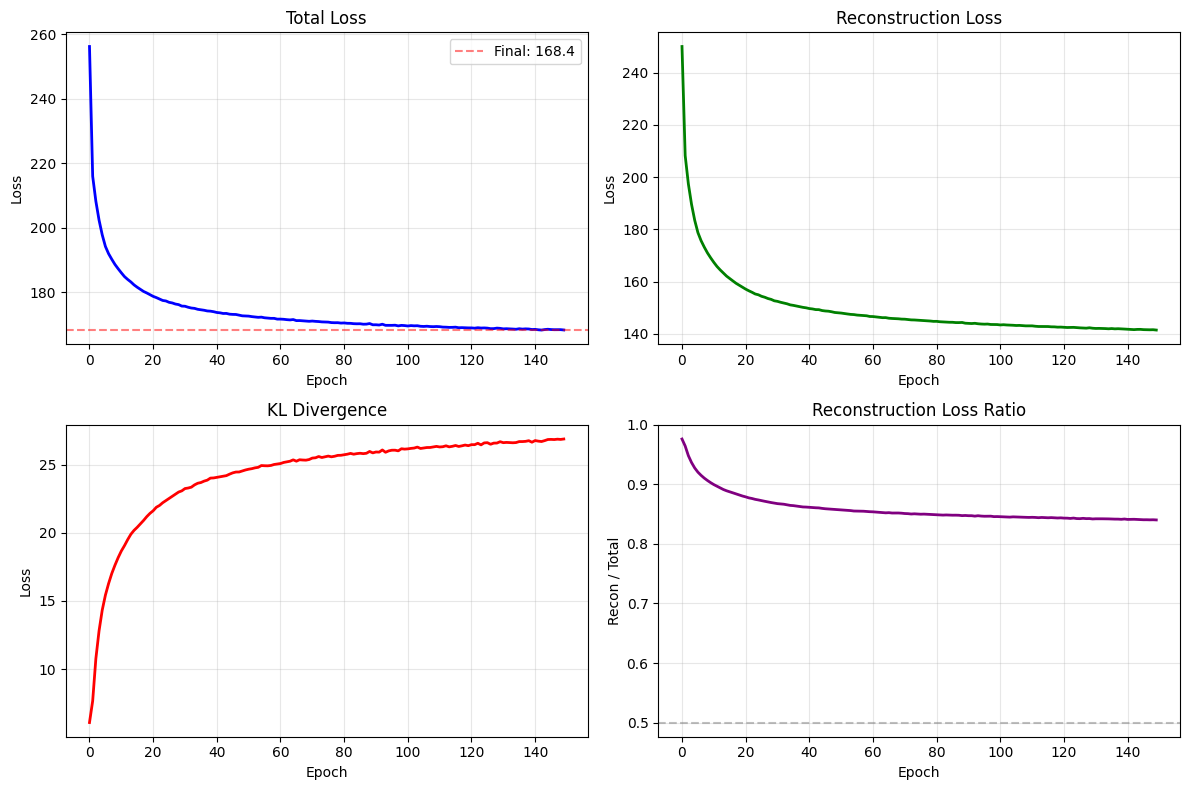


Final Results:
Total Loss: 168.36 (from 256.13)
Recon Loss: 141.48 (from 250.05)
KL Loss: 26.88 (from 6.08)


In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Store losses
losses = []
recon_losses = []
kl_losses = []

EPOCHS = 150

for epoch in range(EPOCHS):
    total_loss = 0
    total_recon = 0
    total_kl = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        recon, mu, logvar = model(x, y)

        recon_loss = F.mse_loss(recon, x, reduction='sum') / x.size(0)
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
        loss = recon_loss + kl_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    avg_loss = total_loss / len(loader)
    avg_recon = total_recon / len(loader)
    avg_kl = total_kl / len(loader)

    losses.append(avg_loss)
    recon_losses.append(avg_recon)
    kl_losses.append(avg_kl)

    # Print progress every 5 epochs
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} - Total: {avg_loss:.4f}, Recon: {avg_recon:.4f}, KL: {avg_kl:.4f}")

# Plot after training
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Total loss
axes[0, 0].plot(losses, 'b-', linewidth=2)
axes[0, 0].set_title('Total Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=losses[-1], color='r', linestyle='--', alpha=0.5, label=f'Final: {losses[-1]:.1f}')
axes[0, 0].legend()

# Reconstruction loss
axes[0, 1].plot(recon_losses, 'g-', linewidth=2)
axes[0, 1].set_title('Reconstruction Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].grid(True, alpha=0.3)

# KL loss
axes[1, 0].plot(kl_losses, 'r-', linewidth=2)
axes[1, 0].set_title('KL Divergence')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].grid(True, alpha=0.3)

# Loss ratio
recon_ratio = np.array(recon_losses) / np.array(losses)
axes[1, 1].plot(recon_ratio, 'purple', linewidth=2)
axes[1, 1].set_title('Reconstruction Loss Ratio')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recon / Total')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\nFinal Results:")
print(f"Total Loss: {losses[-1]:.2f} (from {losses[0]:.2f})")
print(f"Recon Loss: {recon_losses[-1]:.2f} (from {recon_losses[0]:.2f})")
print(f"KL Loss: {kl_losses[-1]:.2f} (from {kl_losses[0]:.2f})")

In [ ]:
def generate_sample(model, genre_label, num_samples=1):
    model.eval()

    with torch.no_grad():
        z = torch.randn(num_samples, LATENT_DIM).to(device)
        y = torch.tensor([genre_label]*num_samples).to(device)

        samples = model.decode(z, y)

    return samples.cpu().numpy()

In [ ]:
def pianoroll_to_midi(piano_roll, filename="output.mid", fs=10):
    pm = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=0)

    for pitch in range(128):
        note_on = None
        for t in range(piano_roll.shape[0]):
            if piano_roll[t, pitch] > 0.5:
                if note_on is None:
                    note_on = t
            else:
                if note_on is not None:
                    note = pretty_midi.Note(
                        velocity=100,
                        pitch=pitch,
                        start=note_on/fs,
                        end=t/fs
                    )
                    instrument.notes.append(note)
                    note_on = None

    pm.instruments.append(instrument)
    pm.write(filename)

In [ ]:
genres = ["jazz", "classical", "rock"]

for i in range(8):
    g = i % 3
    sample = generate_sample(model, g)[0]

    filename = f"/kaggle/working/sample_{genres[g]}_{i}.mid"
    pianoroll_to_midi(sample, filename)

In [ ]:
# Save the model
torch.save(model.state_dict(), '/kaggle/working/vae_music_model.pth')
print("✓ Model saved to /kaggle/working/vae_music_model.pth")

✓ Model saved to /kaggle/working/vae_music_model.pth


In [ ]:
print("\n--- Individual Task 2 VAE File Metrics ---")
print(f"{'Filename':<30} {'PitchSim↓':>10} {'RhythmDiv↑':>12} {'RepRatio':>10}")
print("=" * 72)

for midi_file in t2_files:
    try:
        ps = pitch_histogram_similarity(midi_file, ref_midi)
        rd = rhythm_diversity(midi_file)
        rr = repetition_ratio(midi_file)
        print(f"{midi_file.name:<30} {ps:>10.4f} {rd:>12.4f} {rr:>10.4f}")
    except Exception as e:
        print(f"{midi_file.name:<30} {'Error':>10} {'Error':>12} {'Error':>10} - {e}")


--- Individual Task 2 VAE File Metrics ---
Filename                        PitchSim↓   RhythmDiv↑   RepRatio
sample_classical_1.mid             1.0557       0.5294     0.1250
sample_classical_4.mid             1.4036       0.4000     0.0714
sample_classical_7.mid             1.7587       0.1667     0.2727
sample_jazz_0.mid                  1.0704       0.2708     0.1489
sample_jazz_3.mid                  1.1403       0.2558     0.1667
sample_jazz_6.mid                  1.0995       0.5294     0.0625
sample_rock_2.mid                  0.9817       0.2391     0.0444
sample_rock_5.mid                  0.9850       0.6923     0.0000


In [ ]:
import numpy as np
from pathlib import Path
import pretty_midi
import torch
import torch.nn.functional as F
import re


class MockVAE(torch.nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, x):
        return torch.randn_like(x), torch.zeros(1), torch.zeros(1), torch.zeros(1)
vae = MockVAE()
test_loader = [(torch.randn(10, 10), None)] # Dummy test_loader for reconstruction loss calculation
DEVICE = torch.device("cpu")

t1_dir_path = Path("/content/Task1MidiFiles/")
t2_dir_path = Path("/content/Task2Midifiles/")

# Ensure directories exist (important if running this code for the first time or if paths are dynamic)
t1_dir_path.mkdir(parents=True, exist_ok=True)
t2_dir_path.mkdir(parents=True, exist_ok=True)

# Task 1 files
t1_files = sorted(t1_dir_path.glob("sample_*.mid"))

# Task 2 VAE files: Updating CONFIG_T2 and using actual files from t2_dir_path
CONFIG_T2 = {"midi_out_dir": str(t2_dir_path)}
# Assuming VAE-generated files will also be named 'sample_*.mid' or these are the ones to analyze
t2_files = sorted(t2_dir_path.glob("sample_*.mid"))

# Populate GENRES and genre_files based on available files in t2_dir_path
# This assumes genre is part of the filename (e.g., 'sample_classical_7.mid')
GENRES = []
genre_files = {}
for midi_file in t2_dir_path.glob("sample_*.mid"):
    # Extract genre from filename, e.g., 'sample_classical_7.mid' -> 'classical'
    match = re.search(r'sample_([a-zA-Z]+)_', midi_file.name)
    if match:
        genre = match.group(1)
        if genre not in GENRES:
            GENRES.append(genre)
        if genre not in genre_files:
            genre_files[genre] = []
        genre_files[genre].append(midi_file)

# Sort files for consistency
for g in GENRES:
    genre_files[g].sort()

# Reference MIDI — first available file from any genre
ref_midi = "/content/MIDI-Unprocessed_11_R1_2009_06-09_ORIG_MID--AUDIO_11_R1_2009_11_R1_2009_07_WAV.midi"
if ref_midi is None:
    raise RuntimeError("No reference MIDI found in Task2Midifiles — check dataset paths or filenames.")

print(f"Reference: {Path(ref_midi).name}\n")

ps1, rd1, rr1 = avg_metrics(t1_files, ref_midi)
ps2, rd2, rr2 = avg_metrics(t2_files, ref_midi)



print(f"{'Model':<25} {'PitchSim↓':>10} {'RhythmDiv↑':>12} {'RepRatio':>10}")
print("=" * 72)
print(f"{'Task1 LSTM-AE':<25} {ps1:>10.4f} {rd1:>12.4f} {rr1:>10.4f} ")
print(f"{'Task2 VAE':<25} {ps2:>10.4f} {rd2:>12.4f} {rr2:>10.4f} ")

Reference: MIDI-Unprocessed_11_R1_2009_06-09_ORIG_MID--AUDIO_11_R1_2009_11_R1_2009_07_WAV.midi

Model                      PitchSim↓   RhythmDiv↑   RepRatio
Task1 LSTM-AE                 0.6268       0.3457     0.0158 
Task2 VAE                     1.1869       0.3854     0.1115 
